### Business Problem:

#### Policy makers aim to implement agricultural policies that promote sustainable farming practices and improve food security by understanding crop production patterns over the years across different regions and seasons in India.

### objective

#### To understand & analyze crop production patterns in different regions of india over the years for sustainable strategies to enhance crop productivity & food security and help farmers in crop selection in their regions in different seasons for production and profitability

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Collection:

In [4]:
cp=pd.read_csv(r"C:\Users\sujit\Downloads\APY.csv\APY.csv")
cp.columns

Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')

In [5]:
cp.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


In [6]:
cp.shape #size of the data

(345336, 8)

### Data Cleaning:

In [7]:
cp.isna().sum() #checking for missing values

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

In [8]:
cp[cp.Crop.isna()]

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
273741,Tamil Nadu,COIMBATORE,NaN,1998,Rabi,20.0,1.0,0.05
273742,Tamil Nadu,DINDIGUL,NaN,2002,Rabi,1.0,0.0,0.00
273743,Tamil Nadu,KRISHNAGIRI,NaN,2004,Rabi,1.0,NaN,0.00
273744,Tamil Nadu,NAMAKKAL,NaN,1998,Rabi,250.0,13.0,0.05
273745,Tamil Nadu,RAMANATHAPURAM,NaN,2006,Rabi,3.0,NaN,0.00
273746,Tamil Nadu,SALEM,NaN,1999,Rabi,25.0,12.0,0.48
273747,Tamil Nadu,THE NILGIRIS,NaN,1998,Rabi,430.0,20.0,0.05
273748,Tamil Nadu,TIRUPPUR,NaN,2011,Kharif,2.0,NaN,0.00
273749,Tamil Nadu,VELLORE,NaN,2006,Rabi,4.0,NaN,0.00


##### Handling NAN values

In [9]:
cp['Crop']=cp['Crop'].fillna(cp.groupby(['State', 'Season'])['Crop'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')) #filling missing values with mode (most frequently cultivated crop in their respective state and season

In [10]:
cp['Production']=cp.Production.fillna(cp.groupby(['Crop_Year','State','Season'])['Production'].transform('mean')) ## filling missing values with mean impuation

In [11]:
cp.isna().sum()

State         0
District      0
Crop          0
Crop_Year     0
Season        0
Area          0
Production    7
Yield         0
dtype: int64

In [12]:
cp.Production=cp.Production.fillna(cp.groupby(['State','Crop'])['Production'].transform('mean'))

In [13]:
cp.isna().sum()

State         0
District      0
Crop          0
Crop_Year     0
Season        0
Area          0
Production    0
Yield         0
dtype: int64

In [14]:
cp.rename(columns={'Area ':'Area (hectares)','Production':'Production (Lakh Tons)','Yield':'Yield (Tons/Hectares)','District ':'District'},inplace=True) #renaming column names to make more readable

In [15]:
cp=cp.apply(lambda x:pd.Series(map(str,x)).str.strip()) # found extra white spaces in the data removed white spaces by apply string method .strip()

In [16]:
cp.duplicated().sum() #checking for duplicates

0

In [17]:
cp['State']=cp['State'].astype('category')  #conversion of datatypes to suitable datatypes
cp['District']=cp['District'].astype('category')
cp['Crop']=cp['Crop'].astype('category')
cp['Crop_Year'] = cp['Crop_Year'].astype(int)
cp['Area (hectares)']=cp['Area (hectares)'].astype('float')
cp['Production (Lakh Tons)']=cp['Production (Lakh Tons)'].astype('float')
cp['Yield (Tons/Hectares)']=cp['Yield (Tons/Hectares)'].astype('float')
cp['Season']=cp['Season'].astype('category')

In [18]:
cp['Region'] = cp['State'].map({  #created a new column region for regional analysis
    # North
    "Jammu and Kashmir": "North", "Laddak": "North", "Himachal Pradesh": "North",
    "Punjab": "North", "Haryana": "North", "Delhi": "North", "CHANDIGARH": "North",
    "Uttarakhand": "North", "Uttar Pradesh": "North",

    # South
    "Andhra Pradesh": "South", "Telangana": "South", "Tamil Nadu": "South",
    "Karnataka": "South", "Kerala": "South", "Puducherry": "South",

    # East
    "Bihar": "East", "Jharkhand": "East", "Odisha": "East", "West Bengal": "East",

    # West
    "Rajasthan": "West", "Gujarat": "West", "Maharashtra": "West", "Goa": "West",
    "Dadra and Nagar Haveli": "West", "Daman and Diu": "West", "THE DADRA AND NAGAR HAVELI": "West",

    # Central
    "Madhya Pradesh": "Central", "Chhattisgarh": "Central",

    # Northeast
    "Arunachal Pradesh": "Northeast", "Assam": "Northeast", "Manipur": "Northeast",
    "Meghalaya": "Northeast", "Mizoram": "Northeast", "Nagaland": "Northeast",
    "Tripura": "Northeast", "Sikkim": "Northeast",

    # Island
    "Andaman and Nicobar Island": "Island"
})


In [19]:
cp['Production (Lakh Tons)'] = cp['Production (Lakh Tons)'] / 1e5 #converting tons into lakh tons

In [20]:
cp.columns

Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area (hectares)',
       'Production (Lakh Tons)', 'Yield (Tons/Hectares)', 'Region'],
      dtype='object')

### Data Analysis & visualization

Text(0.5, 1.0, 'Crop Production over the years')

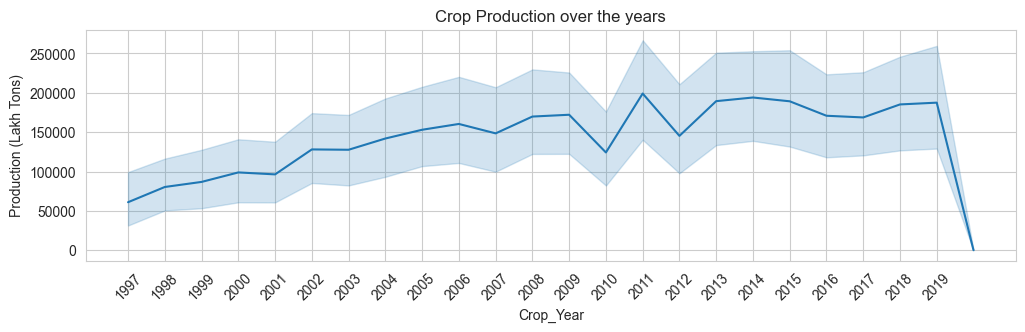

In [70]:
plt.figure(figsize=(12,3))
sns.lineplot(data=cp,x='Crop_Year',y='Production (Lakh Tons)',estimator='sum',legend=True)
plt.xticks(np.arange(1997, 2020, 1),rotation=45)
plt.grid(True)
plt.title('Crop Production over the years')

C:\Users\sujit\AppData\Local\Temp\ipykernel_6104\2510068810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped=cp.groupby(['Crop_Year','Crop'])['Production (Lakh Tons)'].sum().unstack('Crop')


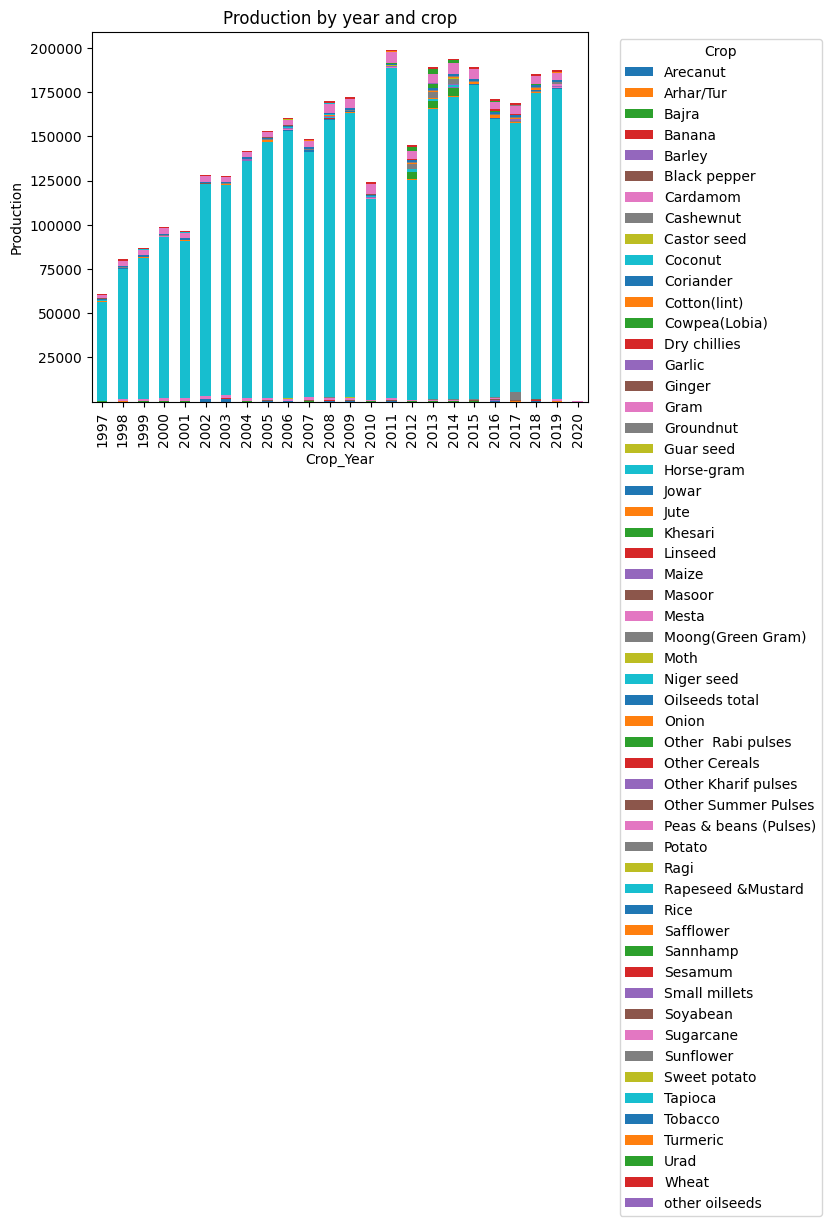

In [29]:
grouped=cp.groupby(['Crop_Year','Crop'])['Production (Lakh Tons)'].sum().unstack('Crop')
pl = grouped.plot.bar(stacked=True)
pl.set_xlabel('Crop_Year')
pl.set_ylabel('Production')
pl.set_title('Production by year and crop')
pl.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### State wise analysis

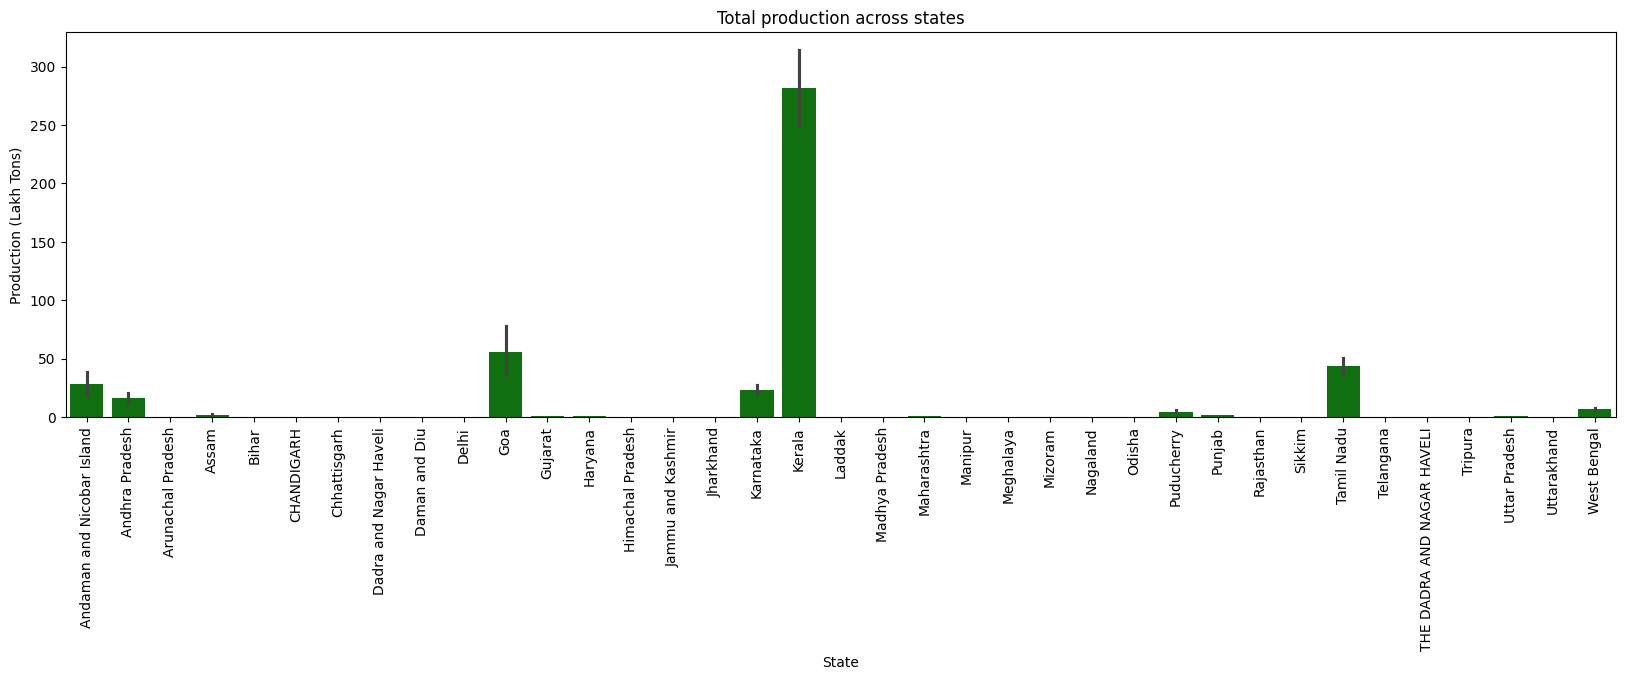

In [32]:
#summ_sorted = summ.sort_values(by='Production (Lakh Tons)', ascending=False)

plt.figure(figsize=(20,5))
sns.barplot(data=cp, x='State', y='Production (Lakh Tons)', 
            order=cp['State'],color='green')  # Use the sorted order of 'State'
plt.xticks(rotation=90)
plt.title('Total production across states')
plt.show()


C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\3599987750.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ=cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index()
C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\3599987750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summ,y='State',x='Yield (Tons/Hectares)',palette='viridis',order=summ_sorted['State'])


Text(0.5, 1.0, 'Yield Productivity across states')

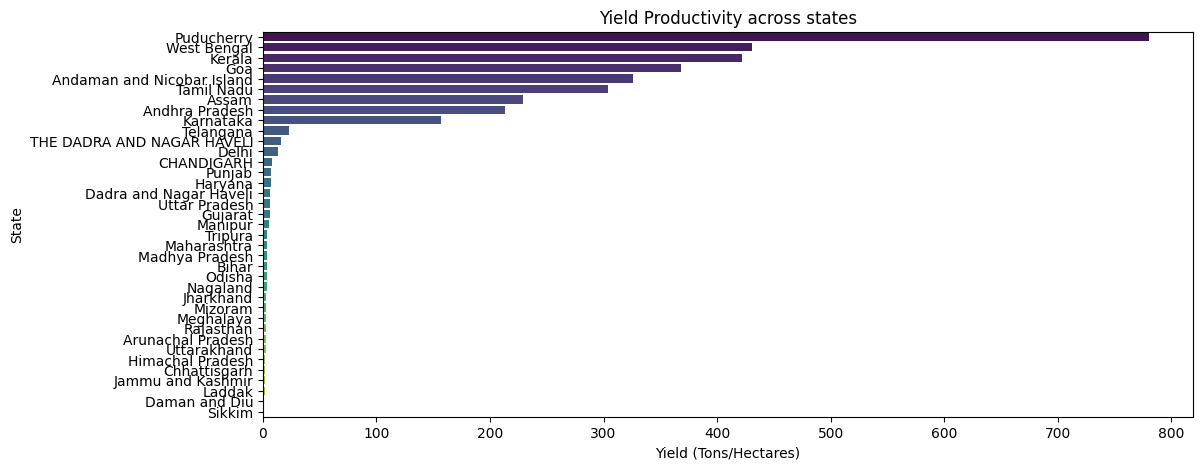

In [258]:
summ=cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index()
summ['Yield (Tons/Hectares)']=summ['Yield (Tons/Hectares)'].map(int)
summ_sorted = summ.sort_values(by='Yield (Tons/Hectares)', ascending=False)
plt.figure(figsize=(12,5))
sns.barplot(data=summ,y='State',x='Yield (Tons/Hectares)',palette='viridis',order=summ_sorted['State'])
plt.title('Yield Productivity across states')

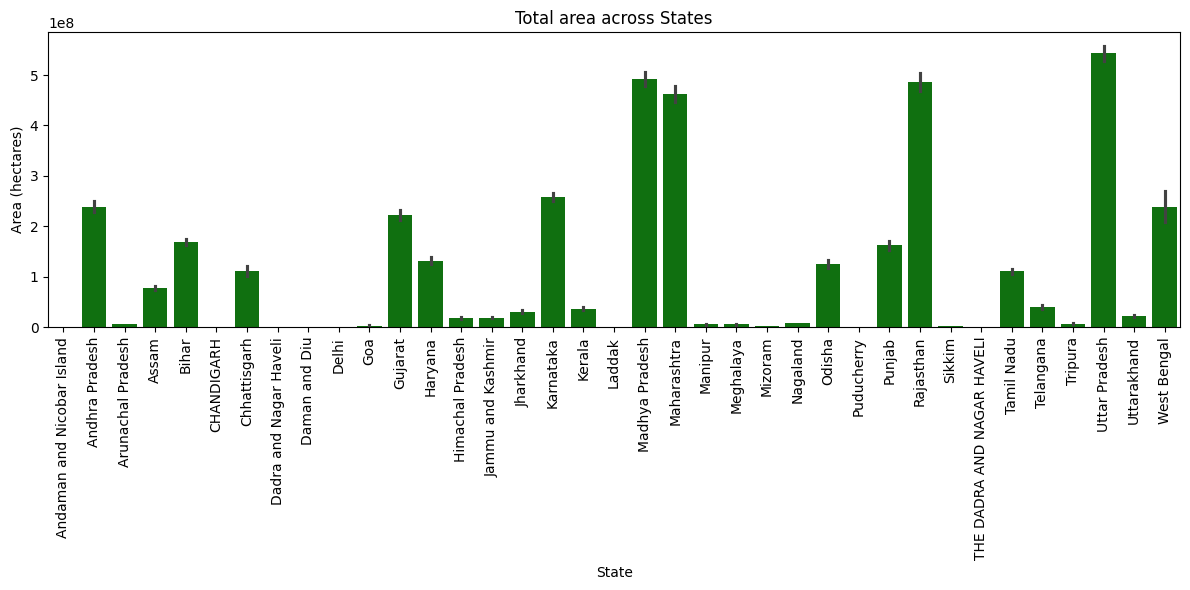

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(data=cp,x='State',y='Area (hectares)',estimator='sum',color='green')
plt.xticks(rotation=90)
plt.title('Total area across States')
plt.tight_layout()
plt.show()

##### Top 5 crops with higher production

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\1039315800.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crop_production = cp.groupby('Crop')['Production (Lakh Tons)'].sum().reset_index()


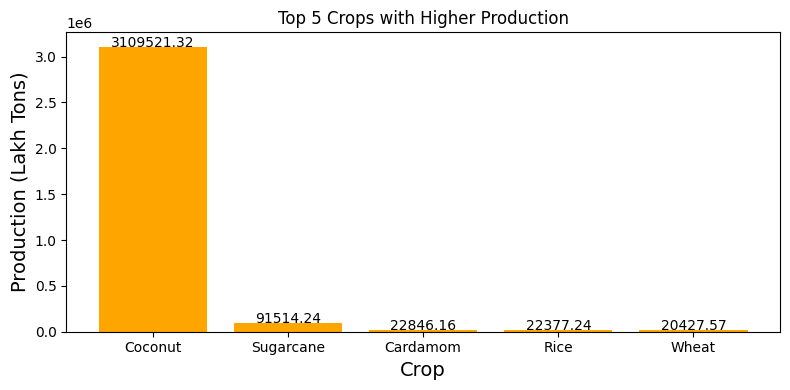

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

crop_production = cp.groupby('Crop')['Production (Lakh Tons)'].sum().reset_index()

top_5_crops = crop_production.sort_values(by='Production (Lakh Tons)', ascending=False).head(5)

plt.figure(figsize=(8,4))
plt.bar(top_5_crops['Crop'], top_5_crops['Production (Lakh Tons)'], color='orange')

plt.title('Top 5 Crops with Higher Production')
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Production (Lakh Tons)', fontsize=14)

for i, value in enumerate(top_5_crops['Production (Lakh Tons)']):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


##### Top 5 crops with lower production

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2068312170.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crop_production = cp.groupby('Crop')['Production (Lakh Tons)'].sum().reset_index()


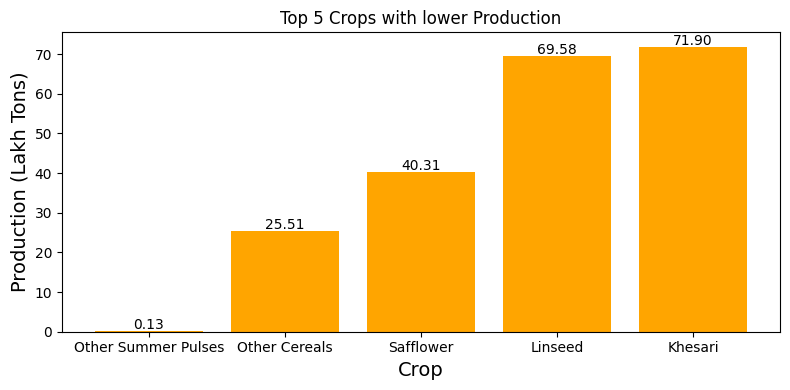

In [351]:
import pandas as pd
import matplotlib.pyplot as plt

crop_production = cp.groupby('Crop')['Production (Lakh Tons)'].sum().reset_index()

top_5_crops = crop_production.sort_values(by='Production (Lakh Tons)', ascending=True).head(5)

plt.figure(figsize=(8,4))
plt.bar(top_5_crops['Crop'], top_5_crops['Production (Lakh Tons)'], color='orange')

plt.title('Top 5 Crops with lower Production')
plt.xlabel('Crop', fontsize=14)
plt.ylabel('Production (Lakh Tons)', fontsize=14)

for i, value in enumerate(top_5_crops['Production (Lakh Tons)']):
    plt.text(i,value+0.5, f'{value:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


#### Top 5 states with higher crop production

In [277]:
cp.groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index().head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\3145446940.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index().head()


,State,Production (Lakh Tons)
0,Kerala,1372309
1,Tamil Nadu,808520
2,Karnataka,645009
3,Andhra Pradesh,265169
4,West Bengal,89439


#### Top 5 states with lower crop production

In [279]:
cp.groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=True).apply(lambda x:f"{x:.0f}").reset_index().head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1461222584.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=True).apply(lambda x:f"{x:.0f}").reset_index().head()


,State,Production (Lakh Tons)
0,Daman and Diu,1
1,CHANDIGARH,1
2,Laddak,1
3,Dadra and Nagar Haveli,3
4,THE DADRA AND NAGAR HAVELI,22


#### states with higher yield efficiency

In [280]:
cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index().head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1095133671.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=False).apply(lambda x:f"{x:.0f}").reset_index().head()


,State,Yield (Tons/Hectares)
0,Puducherry,780
1,West Bengal,431
2,Kerala,422
3,Goa,368
4,Andaman and Nicobar Island,326


#### states with lower yield efficiency

In [281]:
cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=True).apply(lambda x:f"{x:.0f}").reset_index().head()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2027241066.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('State')['Yield (Tons/Hectares)'].mean().sort_values(ascending=True).apply(lambda x:f"{x:.0f}").reset_index().head()


,State,Yield (Tons/Hectares)
0,Sikkim,1
1,Daman and Diu,1
2,Laddak,2
3,Jammu and Kashmir,2
4,Chhattisgarh,2


#### crop analysis

#### Top performing crops per state

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2066758999.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_grouped = cp.groupby(['State', 'Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index()
C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2066758999.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = top_crops.groupby('State').head(2)


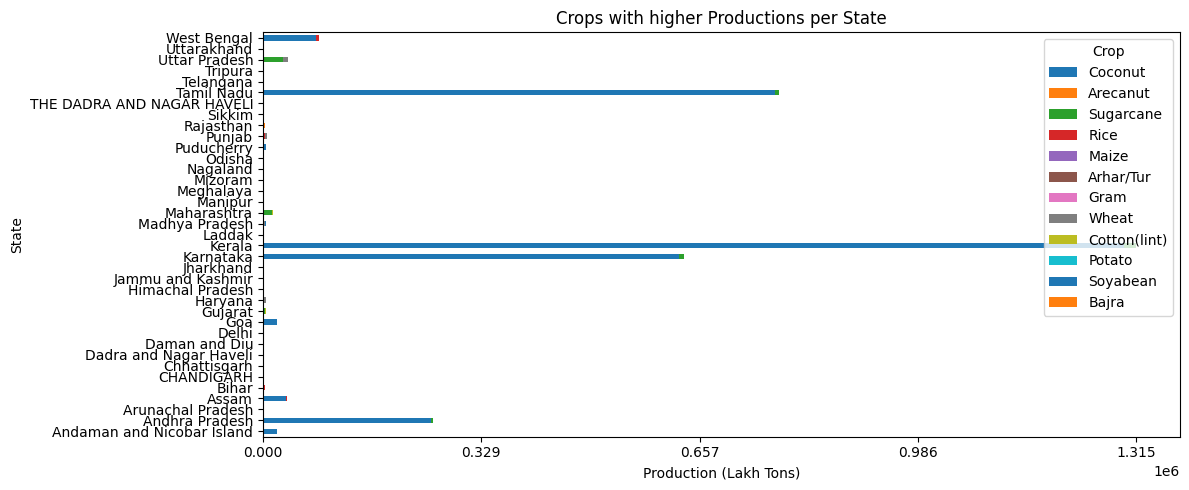

In [286]:
cp_grouped = cp.groupby(['State', 'Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index()
top_crops = cp_grouped.sort_values(['State', 'Production (Lakh Tons)'], ascending=[True, False])
top2 = top_crops.groupby('State').head(2)
pivot_df = top2.pivot(index='State', columns='Crop', values='Production (Lakh Tons)')
pivot_df = pivot_df.fillna(0)
pivot_df.plot(kind='barh', stacked=True, figsize=(12,5))

plt.title('Crops with higher Productions per State')
plt.ylabel('State')
plt.xlabel('Production (Lakh Tons)')
max_value = pivot_df.sum(axis=1).max()
plt.xticks(np.linspace(0, max_value, num=5))  

plt.legend(title='Crop')
plt.tight_layout()
plt.show()

In [19]:
# cp_grouped = cp.groupby(['State', 'Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index()
# top_crops = cp_grouped.sort_values(['State', 'Production (Lakh Tons)'], ascending=[True, True])
# top2 = top_crops.groupby('State').head(2)
# top2
# # pivot_df = top2.pivot(index='State', columns='Crop', values='Production (Lakh Tons)')
# # pivot_df = pivot_df.fillna(0)
# # pivot_df.plot(kind='barh', stacked=True, figsize=(12,5))

# # plt.title('Crops with lower Productions per State')
# # plt.ylabel('State')
# # plt.xlabel('Production (Lakh Tons)')
# # max_value = pivot_df.sum(axis=1).max()
# # plt.xticks(np.linspace(0, max_value, num=5))  

# # plt.legend(title='Crop')
# # plt.tight_layout()
# # plt.show()

#### Seasonal analysis

##### production by season

In [353]:
cp.groupby('Season')['Production (Lakh Tons)'].sum().apply(lambda x:f"{x:.0f}").map(int).sort_values(ascending=False).reset_index()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2966212085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('Season')['Production (Lakh Tons)'].sum().apply(lambda x:f"{x:.0f}").map(int).sort_values(ascending=False).reset_index()


,Season,Production (Lakh Tons)
0,Whole Year,3281042
1,Kharif,57205
2,Rabi,32180
3,Winter,5882
4,Summer,2445
5,Autumn,848


C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2573092703.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('Season')['Production (Lakh Tons)'].sum().plot(


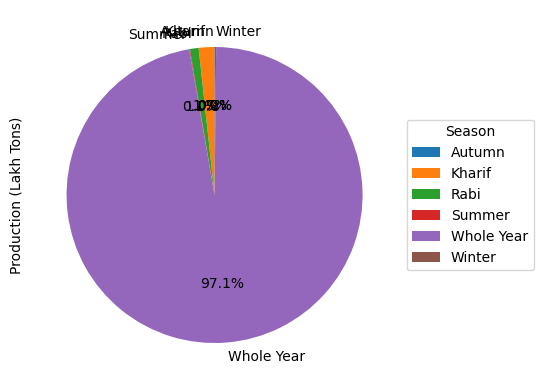

In [354]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

cp.groupby('Season')['Production (Lakh Tons)'].sum().plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    startangle=90,     
    legend=False
)

ax.set_aspect('equal')

ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    title='Season'
)

plt.tight_layout()
plt.show()


##### yield by season

In [355]:
cp.groupby('Season')['Yield (Tons/Hectares)'].mean().apply(lambda x:f"{x:.0f}").map(int).sort_values(ascending=False).reset_index()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\2328273523.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('Season')['Yield (Tons/Hectares)'].mean().apply(lambda x:f"{x:.0f}").map(int).sort_values(ascending=False).reset_index()


,Season,Yield (Tons/Hectares)
0,Whole Year,389
1,Winter,6
2,Summer,3
3,Autumn,2
4,Kharif,2
5,Rabi,2


C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\984976616.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('Season')['Yield (Tons/Hectares)'].sum().plot(


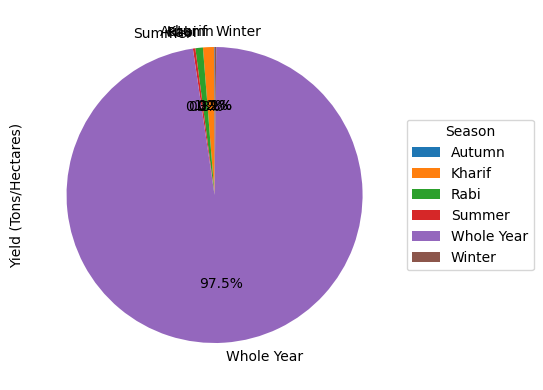

In [300]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

cp.groupby('Season')['Yield (Tons/Hectares)'].sum().plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',
    startangle=90,     
    legend=False      
)

ax.set_aspect('equal')

ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    title='Season'
)

plt.tight_layout()
plt.show()


C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1873988936.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_grouped_season = cp.groupby(['Season', 'Crop'], as_index=False)['Production (Lakh Tons)'].sum()
C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1873988936.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = top_crops.groupby('Season').head(2)


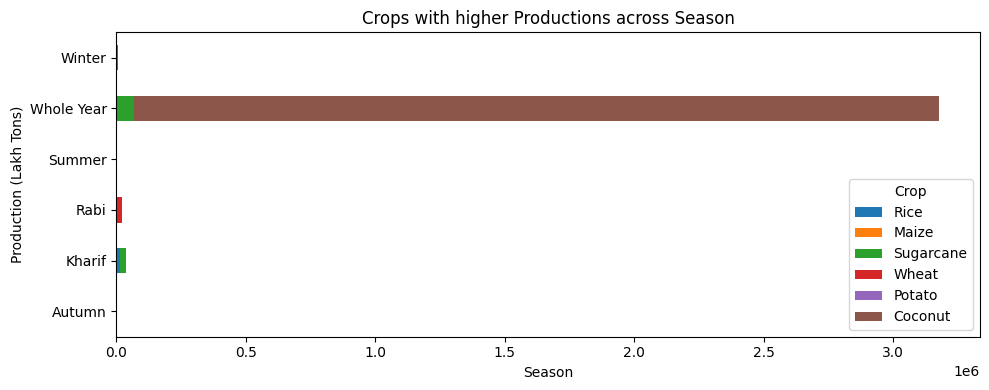

In [356]:
cp_grouped_season = cp.groupby(['Season', 'Crop'], as_index=False)['Production (Lakh Tons)'].sum()
top_crops = cp_grouped_season.sort_values(['Season', 'Production (Lakh Tons)'], ascending=[True, False])
top2 = top_crops.groupby('Season').head(2)
pivot_df = top2.pivot(index='Season', columns='Crop', values='Production (Lakh Tons)')
pivot_df = pivot_df.fillna(0)
import matplotlib.pyplot as plt
pivot_df.plot(kind='barh', stacked=True, figsize=(10,4))
plt.title('Crops with higher Productions across Season')
plt.xlabel('Season')
plt.ylabel('Production (Lakh Tons)')
plt.legend(title='Crop')
plt.tight_layout()
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\873066073.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Season=='Kharif'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in kharif",color='green')


<Axes: title={'center': 'Top 5 states with higher production in kharif'}, xlabel='State', ylabel='Production (Lakh tons)'>

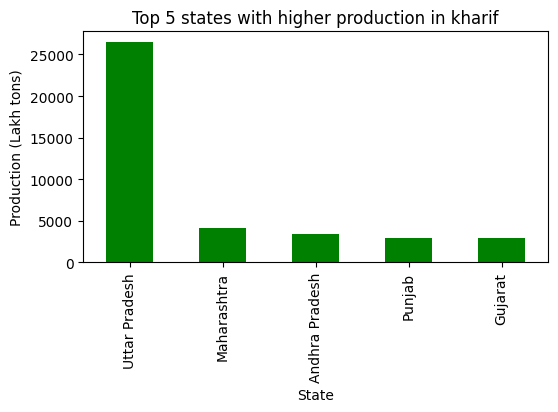

In [54]:
cp[cp.Season=='Kharif'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in kharif",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\813495687.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Season=='Rabi'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Rabi",color='green')


<Axes: title={'center': 'Top 5 states with higher production in Rabi'}, xlabel='State', ylabel='Production (Lakh tons)'>

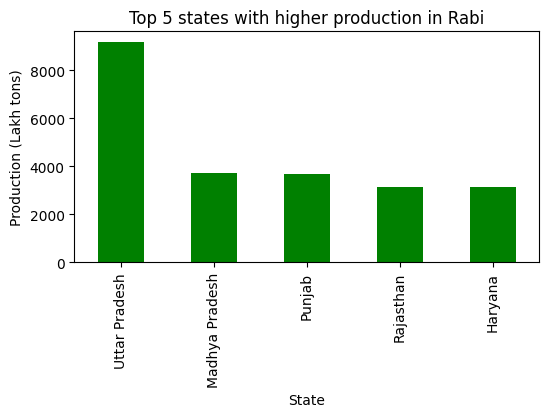

In [55]:
cp[cp.Season=='Rabi'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Rabi",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\707063486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Season=='Summer'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Summer",color='green')


<Axes: title={'center': 'Top 5 states with higher production in Summer'}, xlabel='State', ylabel='Production (Lakh tons)'>

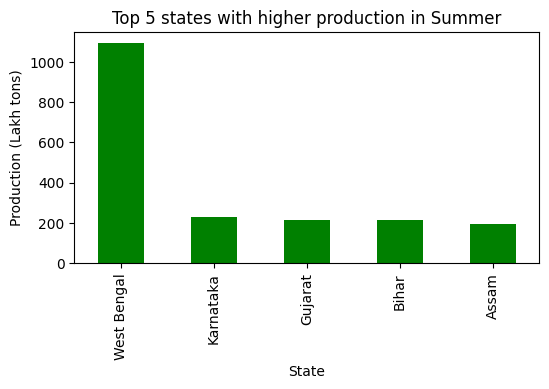

In [56]:
cp[cp.Season=='Summer'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Summer",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\485760040.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Season=='Winter'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Winter",color='green')


<Axes: title={'center': 'Top 5 states with higher production in Winter'}, xlabel='State', ylabel='Production (Lakh tons)'>

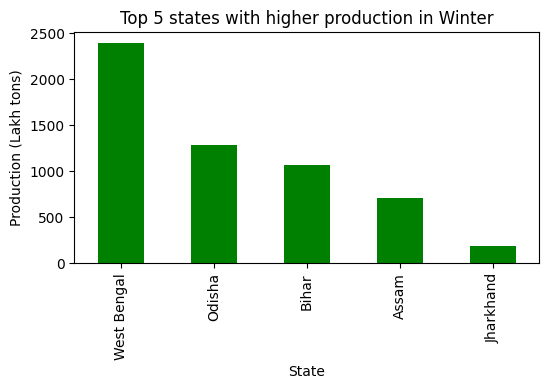

In [57]:
cp[cp.Season=='Winter'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in Winter",color='green')

#### Regional analysis

In [211]:
cp.groupby('Region')['Production (Tons)'].sum().sort_values(ascending=False).apply(lambda x:f"{x:,.2f}").reset_index()

,Region,Production (Tons)
0,South,"309,743,283,107.49"
1,East,"9,727,298,810.43"
2,North,"6,210,209,897.69"
3,West,"5,496,878,543.70"
4,Northeast,"3,725,704,148.45"
5,Island,"2,062,583,559.15"
6,Central,"994,295,485.38"


In [223]:
cp.groupby('Region')['Yield (Tons/Hectares)'].mean().sort_values(ascending=False).apply(lambda x:f"{x:,.2f}").reset_index()

,Region,Yield (Tons/Hectares)
0,Island,326.05
1,South,225.50
2,Northeast,103.08
3,East,95.65
4,West,6.85
5,North,5.16
6,Central,3.18


C:\Users\sujit\AppData\Local\Temp\ipykernel_24740\2686064115.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_grouped_season = cp.groupby(['Region', 'Crop'], as_index=False)['Production (Tons)'].sum()


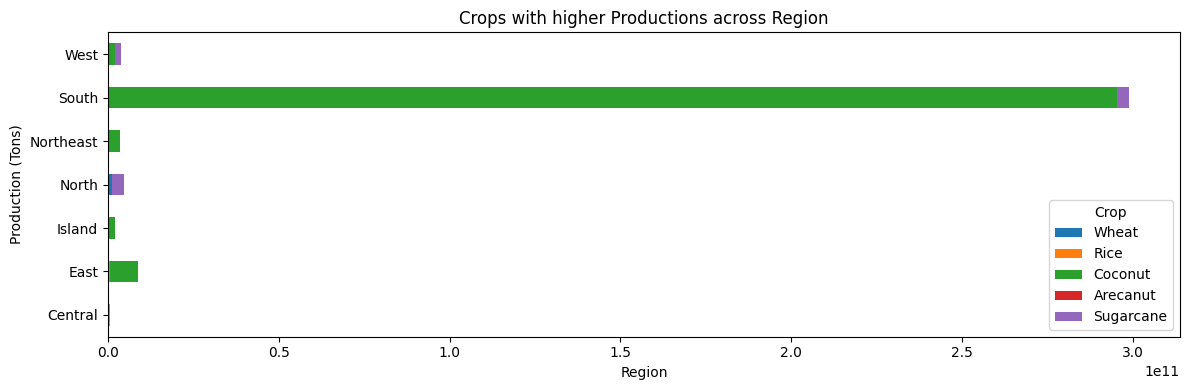

In [38]:
cp_grouped_season = cp.groupby(['Region', 'Crop'], as_index=False)['Production (Tons)'].sum()
top_crops = cp_grouped_season.sort_values(['Region', 'Production (Tons)'], ascending=[True, False])
top2 = top_crops.groupby('Region').head(2)
pivot_df = top2.pivot(index='Region', columns='Crop', values='Production (Tons)')
pivot_df = pivot_df.fillna(0)
pivot_df.plot(kind='barh', stacked=True, figsize=(12,4))
plt.title('Crops with higher Productions across Region')
plt.xlabel('Region')
plt.ylabel('Production (Tons)')
plt.legend(title='Crop')
plt.tight_layout()
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\634894106.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp['Region']=='South'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in South",color='green')


<Axes: title={'center': 'Top 5 states with higher production in South'}, xlabel='State', ylabel='Production (Lakh tons)'>

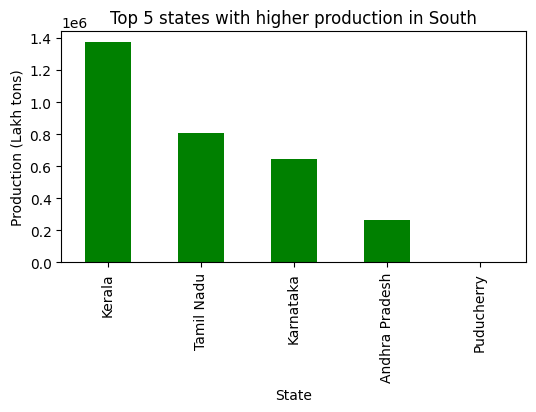

In [45]:
cp[cp['Region']=='South'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in South",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\3460766291.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp['Region']=='East'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in East",color='green')


<Axes: title={'center': 'Top 5 states with higher production in East'}, xlabel='State', ylabel='Production (Lakh tons)'>

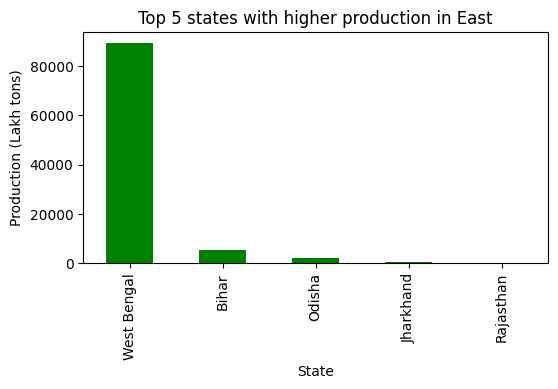

In [46]:
cp[cp['Region']=='East'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in East",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\4025325791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp['Region']=='North'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in North",color='green')


<Axes: title={'center': 'Top 5 states with higher production in North'}, xlabel='State', ylabel='Production (Lakh tons)'>

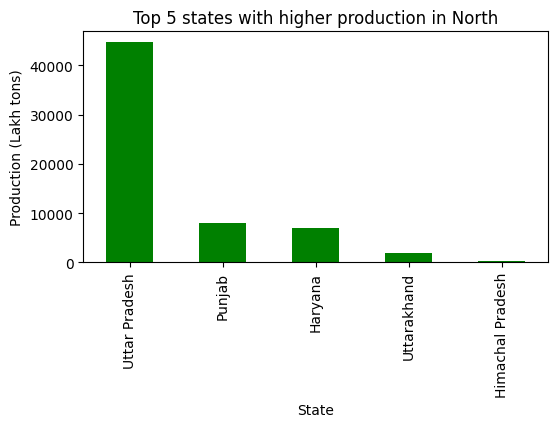

In [48]:
cp[cp['Region']=='North'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in North",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\42114863.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp['Region']=='West'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in West",color='green')


<Axes: title={'center': 'Top 5 states with higher production in West'}, xlabel='State', ylabel='Production (Lakh tons)'>

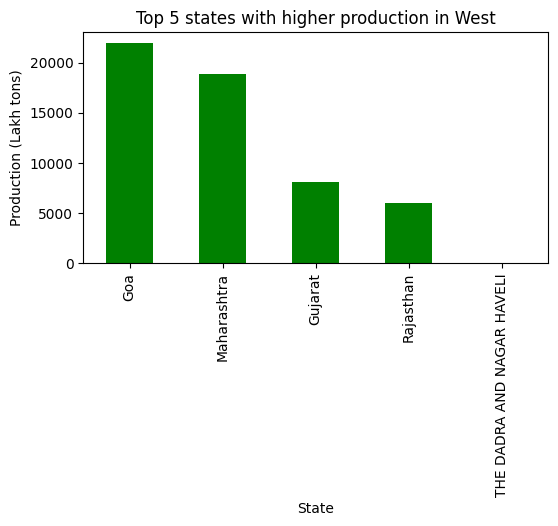

In [49]:
cp[cp['Region']=='West'][['State','Production (Lakh Tons)']].reset_index().drop(columns='index').groupby('State')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(6,3),ylabel='Production (Lakh tons)',title="Top 5 states with higher production in West",color='green')

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\2003756375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Region=='South'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in south',color='green')


<Axes: title={'center': 'top 5 states with higher production in south'}, xlabel='State'>

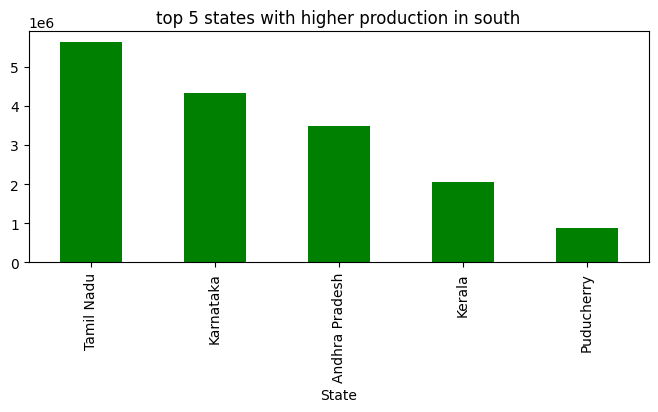

In [50]:
cp[cp.Region=='South'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in south',color='green')


C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\3450871003.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Region=='West'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in west',color='green')


<Axes: title={'center': 'top 5 states with higher production in west'}, xlabel='State'>

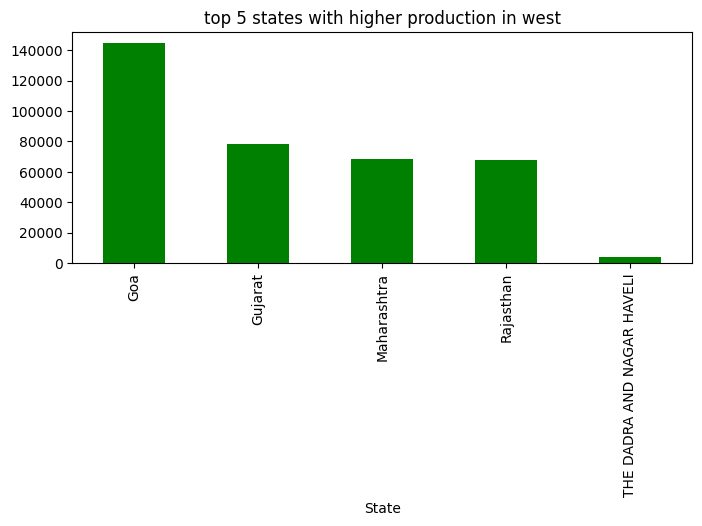

In [51]:
cp[cp.Region=='West'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in west',color='green')


C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\4187677769.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp[cp.Region=='East'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in east',color='green')


<Axes: title={'center': 'top 5 states with higher production in east'}, xlabel='State'>

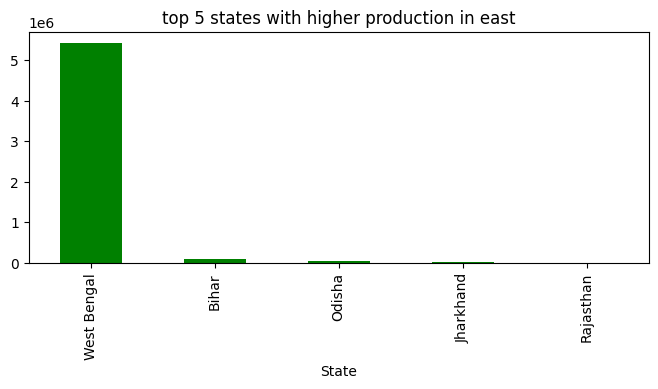

In [52]:
cp[cp.Region=='East'].groupby('State')['Yield (Tons/Hectares)'].sum().sort_values(ascending=False).head(5).plot(kind='bar',figsize=(8,3),title='top 5 states with higher production in east',color='green')

In [44]:
cp.State.nunique()

37

#### district analysis

In [47]:
cp.groupby('District')['Production (Tons)'].sum().map(int).sort_values(ascending=False) # totalproduction by district

C:\Users\sujit\AppData\Local\Temp\ipykernel_24740\622451565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('District')['Production (Tons)'].sum().map(int).sort_values(ascending=False)


District
KOZHIKODE                  21177443885
TUMAKURU                   20809992240
MALAPPURAM                 20181006660
COIMBATORE                 17705634722
THIRUVANANTHAPURAM         13891798778
                              ...     
SHI YOMI                          5897
HYDERABAD                         3835
MUMBAI SUBURBAN                    332
SOUTH SALMARA MANCACHAR            108
MUMBAI                               2
Name: Production (Tons), Length: 707, dtype: int64

<Figure size 2000x600 with 0 Axes>

In [109]:
cp.groupby('District')['Yield (Tons/Hectares)'].sum().map(int).sort_values(ascending=False) # total yield by district

C:\Users\sujit\AppData\Local\Temp\ipykernel_24740\876707145.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('District')['Yield (Tons/Hectares)'].sum().map(int).sort_values(ascending=False) ##total yield by district


District
PARAGANAS SOUTH            665730
MEDINIPUR WEST             352614
HOOGHLY                    346962
DARJEELING                 338825
JALPAIGURI                 325031
                            ...  
HYDERABAD                      15
NIWARI                         10
MUMBAI SUBURBAN                 1
SOUTH SALMARA MANCACHAR         0
MUMBAI                          0
Name: Yield (Tons/Hectares), Length: 707, dtype: int64

#### crops with higher production in each district

In [108]:
cp_grouped_season = cp.groupby(['District', 'Crop'])['Production (Tons)'].sum().map(int).reset_index()
top_crops = cp_grouped_season.sort_values(['District', 'Production (Tons)'], ascending=[True, False])
top2 = top_crops.groupby('District').head(2)
top2

C:\Users\sujit\AppData\Local\Temp\ipykernel_24740\26417168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_grouped_season = cp.groupby(['District', 'Crop'])['Production (Tons)'].sum().map(int).reset_index()
C:\Users\sujit\AppData\Local\Temp\ipykernel_24740\26417168.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top2 = top_crops.groupby('District').head(2)


,District,Crop,Production (Tons)
14,ADILABAD,Garlic,11616397
11,ADILABAD,Cotton(lint),9684901
108,AGAR MALWA,Wheat,1474013
100,AGAR MALWA,Soyabean,756635
147,AGRA,Potato,27685472
...,...,...,...
38760,YANAM,Rice,45145
38786,YAVATMAL,Cotton(lint),12315802
38821,YAVATMAL,Sugarcane,11057187
38870,ZUNHEBOTO,Rice,508798


#### Top 50 districts with higher production

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\156171510.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top50=cp.groupby('District')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(50).plot(kind='bar',figsize=(20,5),title='Top 50 Districts with higher production',color='green')


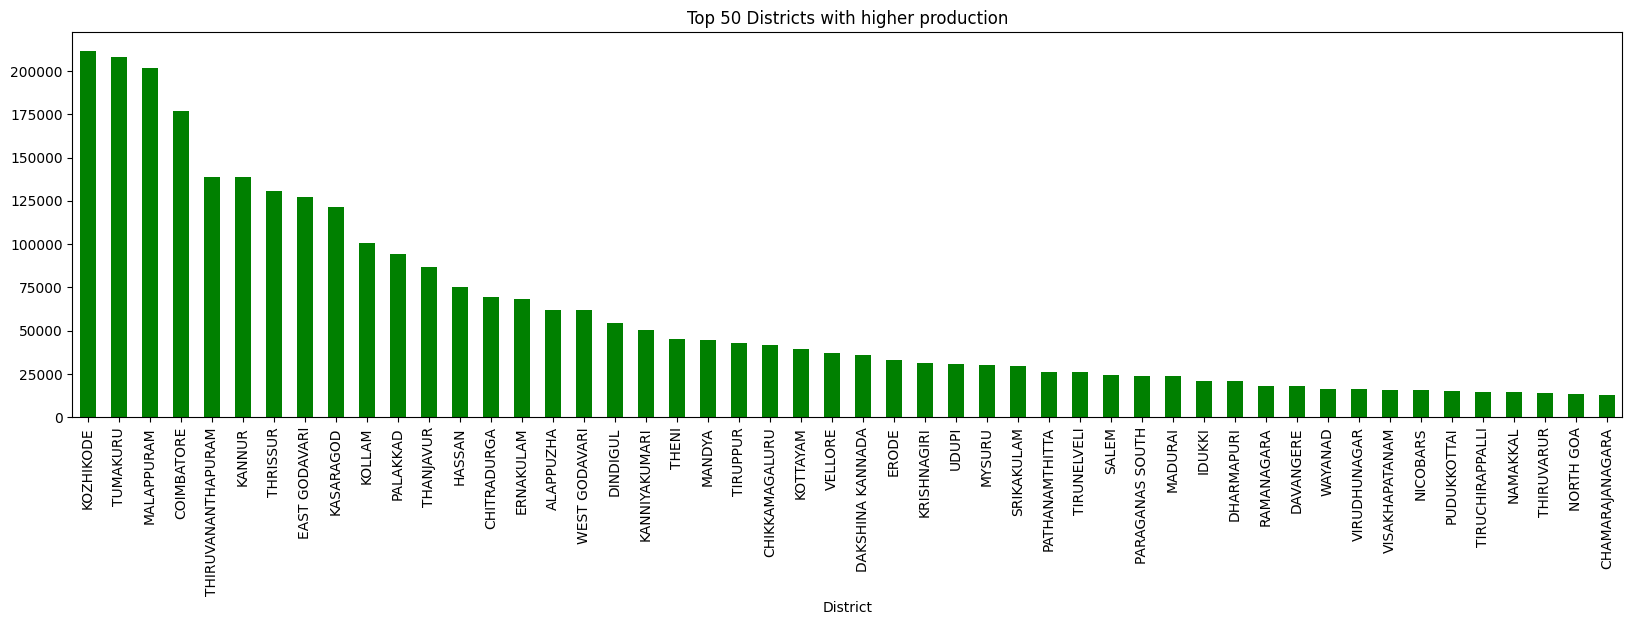

In [33]:
top50=cp.groupby('District')['Production (Lakh Tons)'].sum().sort_values(ascending=False).head(50).plot(kind='bar',figsize=(20,5),title='Top 50 Districts with higher production',color='green')

In [136]:
cp.groupby('District')['Production (Tons)'].sum().sort_values(ascending=False).map(int).head(50).reset_index()

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1441934897.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('District')['Production (Tons)'].sum().sort_values(ascending=False).map(int).head(50).reset_index()


,District,Production (Tons)
0,KOZHIKODE,21177443885
1,TUMAKURU,20809992240
2,MALAPPURAM,20181006660
3,COIMBATORE,17705634722
4,THIRUVANANTHAPURAM,13891798778
5,KANNUR,13887943105
6,THRISSUR,13090729177
7,EAST GODAVARI,12705949795
8,KASARAGOD,12128942370
9,KOLLAM,10060765498


#### Top 50 districts with low production

C:\Users\sujit\AppData\Local\Temp\ipykernel_10524\4146653246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp.groupby('District')['Production (Lakh Tons)'].sum().sort_values(ascending=True).head(50).plot(kind='bar',figsize=(20,5),title='Top 50 District with lower production',color='green')


<Axes: title={'center': 'Top 50 District with lower production'}, xlabel='District'>

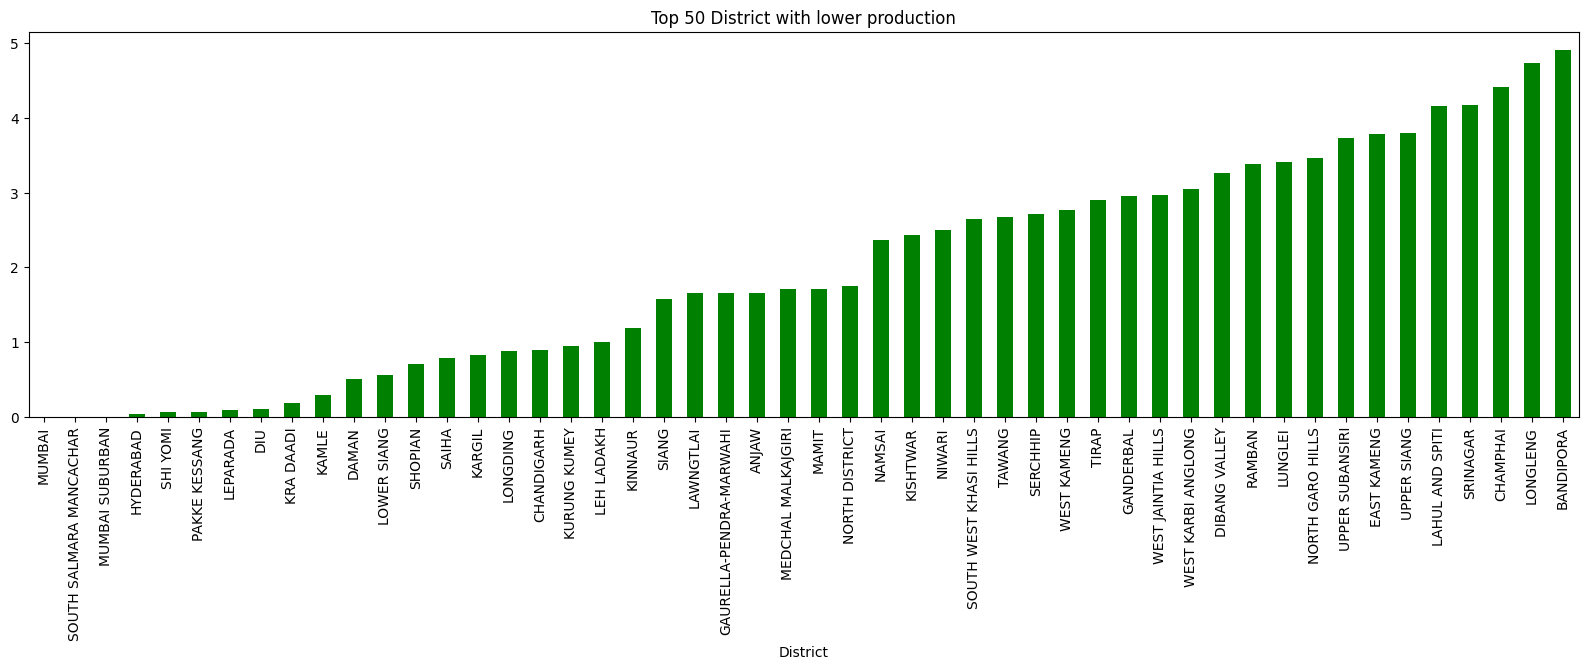

In [34]:
cp.groupby('District')['Production (Lakh Tons)'].sum().sort_values(ascending=True).head(50).plot(kind='bar',figsize=(20,5),title='Top 50 District with lower production',color='green')

#### top 2 crops with high production in each district

In [362]:
summ=cp.groupby(['District','Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index().sort_values(by=['District','Production (Lakh Tons)'],ascending=[True,False])
summ.groupby('District').head(2)                                                                                  

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1146718944.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ=cp.groupby(['District','Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index().sort_values(by=['District','Production (Lakh Tons)'],ascending=[True,False])
C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\1146718944.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ.groupby('District').head(2)


,District,Crop,Production (Lakh Tons)
14,ADILABAD,Garlic,116
11,ADILABAD,Cotton(lint),96
108,AGAR MALWA,Wheat,14
100,AGAR MALWA,Soyabean,7
147,AGRA,Potato,276
...,...,...,...
38720,YANAM,Arecanut,0
38786,YAVATMAL,Cotton(lint),123
38821,YAVATMAL,Sugarcane,110
38870,ZUNHEBOTO,Rice,5


#### top2 crops with lower production across district

In [363]:
summ=cp.groupby(['District','Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index().sort_values(by=['District','Production (Lakh Tons)'],ascending=[True,True])
summ.groupby('District').head(2)   

C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\411820146.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ=cp.groupby(['District','Crop'])['Production (Lakh Tons)'].sum().map(int).reset_index().sort_values(by=['District','Production (Lakh Tons)'],ascending=[True,True])
C:\Users\sujit\AppData\Local\Temp\ipykernel_6596\411820146.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summ.groupby('District').head(2)


,District,Crop,Production (Lakh Tons)
0,ADILABAD,Arecanut,0
2,ADILABAD,Bajra,0
55,AGAR MALWA,Arecanut,0
56,AGAR MALWA,Arhar/Tur,0
110,AGRA,Arecanut,0
...,...,...,...
38721,YANAM,Arhar/Tur,0
38775,YAVATMAL,Arecanut,0
38777,YAVATMAL,Bajra,0
38830,ZUNHEBOTO,Arecanut,0


#### Relation between Production and Yield:

Text(0.5, 1.0, 'Yield vs Production')

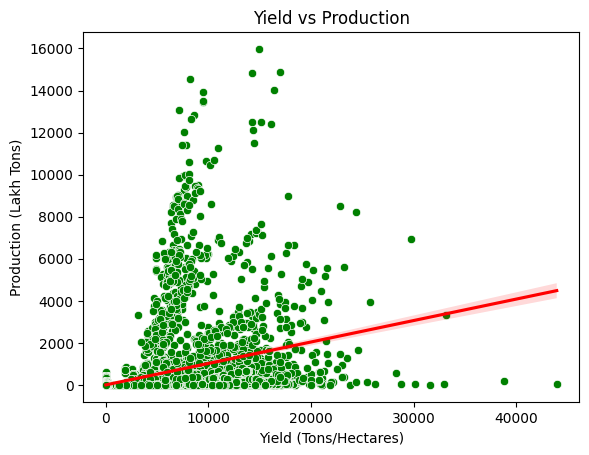

In [58]:
sns.scatterplot(data=cp,y='Production (Lakh Tons)',x='Yield (Tons/Hectares)',color='green')
sns.regplot(data=cp,y='Production (Lakh Tons)',x='Yield (Tons/Hectares)',scatter=False,color='red')
plt.title('Yield vs Production')

#### Key finding in the analysis

##### 1. Higher crops production across south states (Andhra pradesh,Tamilnadu,karnataka,kerala)  and lower production 
#####  in cental states (chattisgarh,madhya pradesh)
##### 2. Coconut, rice, wheat, sugarcane, cardomam are the high produced crops in india over the years
##### 3. coconut is the higly produced crop acoss india
##### 4. Winter,summer, autumn seasonal crops are highly productive compare to other seasons
##### 5. High yiled in island,south,northeast and low yield in west,north,central

#### Business strategies

#### 1. region specific crop planning

###### Encourage cultivation of crops best suited to each region's climate and soil.and providing training for the farmers to select the most suitable crop in their area

#### 2. Optimize Seasonal Cropping Practices

###### Selecting crops that are well-suited to the specific climatic conditions of each season and region
##### Rotating different crops across seasons helps maintain soil fertility, control pests, and reduce disease incidence.

#### 3. Support for Low-Performing Areas

###### conducting soil test, give access to quality of seeds, farmer training to boost productivity

#### 4. Promote Sustainable Practices

###### identified with regions/states low yields and production recommended them to provide incentives to farmers for  organic farming,crop rotation,less chemical input , water efficient techiniques for sustainable agriculture

#### Conclusion

##### Implementing these strategies will not only increase food security but also support farmers' livelihoods and protect natural resources for future generations